In [2]:
import pandas as pd
import importlib

from UniversoActivos import UniversoActivosEstatico, UniversoActivosDinamico
from ProveedorDatos import YFinanceProvider
from VariablesTransformation import FeatureEngineer
import Modelos
Modelos = importlib.reload(Modelos)
from Estrategia import EstrategiaMLEquiponderada, EstrategiaMLMinVarAlphaTilt
from Backtest import BacktestEngine

RandomForestModel = Modelos.RandomForestModel
XGBoostModel = Modelos.XGBoostModel

# EURO STOXX 50

In [3]:
import pandas as pd
import requests

def get_eurostoxx50_tickers():
    url = 'https://en.wikipedia.org/wiki/EURO_STOXX_50'
    
    # Añadimos una cabecera para simular un navegador real
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
    }
    
    # Hacemos la petición con requests
    response = requests.get(url, headers=headers)
    
    # Pasamos el contenido HTML (response.text) a pandas
    tables = pd.read_html(response.text)
    
    # Buscamos la tabla que contiene la columna 'Ticker'
    df = next(table for table in tables if 'Ticker' in table.columns)
    
    return df['Ticker'].tolist()

tickers = get_eurostoxx50_tickers()
print(f"Total empresas: {len(tickers)}")
print(f"Muestra: {tickers}")

Total empresas: 50
Muestra: ['ADS.DE', 'ADYEN.AS', 'AD.AS', 'AI.PA', 'AIR.PA', 'ALV.DE', 'ABI.BR', 'ARGX.BR', 'ASML.AS', 'CS.PA', 'BAS.DE', 'BAYN.DE', 'BBVA.MC', 'SAN.MC', 'BMW.DE', 'BNP.PA', 'BN.PA', 'DBK.DE', 'DB1.DE', 'DHL.DE', 'DTE.DE', 'ENEL.MI', 'ENI.MI', 'EL.PA', 'RACE.MI', 'RMS.PA', 'IBE.MC', 'ITX.MC', 'IFX.DE', 'INGA.AS', 'ISP.MI', 'OR.PA', 'MC.PA', 'MBG.DE', 'MUV2.DE', 'NDA-FI.HE', 'PRX.AS', 'RHM.DE', 'SAF.PA', 'SGO.PA', 'SAN.PA', 'SAP.DE', 'SU.PA', 'SIE.DE', 'ENR.DE', 'TTE.PA', 'DG.PA', 'UCG.MI', 'VOW.DE', 'WKL.AS']


C:\Users\jpuerta\AppData\Local\Temp\ipykernel_195544\1949759624.py:16: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


## XGBoost + EstrategiaMLEquiponderada

[*********************100%***********************]  54 of 54 completed
[*********************100%***********************]  54 of 54 completed
c:\Users\jpuerta\OneDrive - Analistas Financieros Internacionales (Afi)\Documentos\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\ProveedorDatos.py:72: FutureWarning: DataFrameGroupBy.resample operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weekly = weekly.agg(


Modelo entrenado en fecha 2022-11-09
Modelo entrenado en fecha 2023-05-10
Modelo entrenado en fecha 2023-11-08
Modelo entrenado en fecha 2024-05-08
Modelo entrenado en fecha 2024-11-06
Modelo entrenado en fecha 2025-05-07
Modelo entrenado en fecha 2025-11-05


[*********************100%***********************]  1 of 1 completed


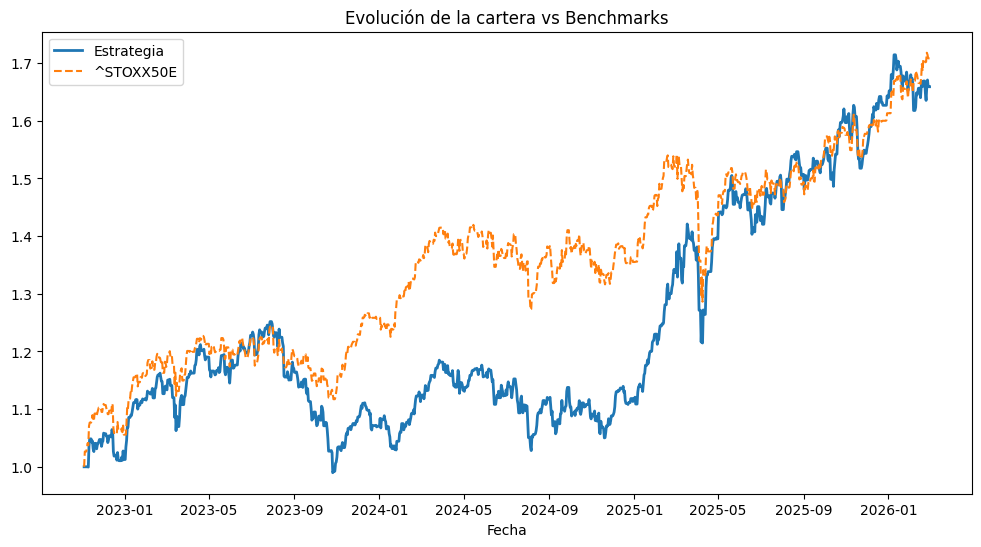

,Estrategia,^STOXX50E
Rentabilidad total,65.91%,70.84%
Rentabilidad anualizada,11.08%,11.76%
Volatilidad anualizada,13.84%,12.38%
Sharpe,0.83,0.96
Sortino,1.17,1.37
Max Drawdown,-20.93%,-16.58%
Calmar,0.53,0.71
Win rate,39.21%,36.90%
Mejor periodo,4.73%,4.26%
Peor periodo,-4.56%,-4.81%


In [4]:
start_date = "2022-11-03"
end_date = "2026-03-01"
universo = UniversoActivosDinamico(tickers_actuales=tickers, start_date=start_date, end_date=end_date, csv_cambios_path=r"eurostoxx50_historico_cambios.csv")
proveedor = YFinanceProvider()
fe = FeatureEngineer(criterio=5, ticker_indice="^STOXX50E")
modelo = XGBoostModel(n_estimators=180, max_depth=4, class_weight=None, random_state=42, positive_class_weight=5.0)
estrategia = EstrategiaMLEquiponderada(modelo=modelo, n_activos_obj=10, umbral_salida=15)
engine = BacktestEngine(
    universo=universo,
    proveedor=proveedor,
    feature_engineer=fe,
    estrategia=estrategia,
    start_date=start_date,
    end_date=end_date,
    len_ventana=4,
    nominal=10000000
)
res1 = engine.print_results(bmks=["^STOXX50E"])

## Random Forest + EstrategiaMLEquiponderada

$STM.MI: possibly delisted; no timezone found
[**********************46%                       ]  28 of 61 completed$STLA.MI: possibly delisted; no timezone found
[*********************100%***********************]  61 of 61 completed

2 Failed downloads:
['STM.MI', 'STLA.MI']: possibly delisted; no timezone found
$STM.MI: possibly delisted; no timezone found
[********************* 44%                       ]  27 of 61 completed$STLA.MI: possibly delisted; no timezone found
[*********************100%***********************]  61 of 61 completed

2 Failed downloads:
['STM.MI', 'STLA.MI']: possibly delisted; no timezone found
c:\Users\jpuerta\OneDrive - Analistas Financieros Internacionales (Afi)\Documentos\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\ProveedorDatos.py:72: FutureWarning: DataFrameGroupBy.resample operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded

Modelo entrenado en fecha 2010-01-06
Modelo entrenado en fecha 2010-07-07
Modelo entrenado en fecha 2011-01-05
Modelo entrenado en fecha 2011-07-06
Modelo entrenado en fecha 2012-01-04
Modelo entrenado en fecha 2012-07-04
Modelo entrenado en fecha 2013-01-02
Modelo entrenado en fecha 2013-07-03
Modelo entrenado en fecha 2014-01-01
Modelo entrenado en fecha 2014-07-02
Modelo entrenado en fecha 2014-12-31
Modelo entrenado en fecha 2015-07-01
Modelo entrenado en fecha 2015-12-30
Modelo entrenado en fecha 2016-06-29
Modelo entrenado en fecha 2016-12-28
Modelo entrenado en fecha 2017-06-28
Modelo entrenado en fecha 2017-12-27
Modelo entrenado en fecha 2018-06-27
Modelo entrenado en fecha 2018-12-26
Modelo entrenado en fecha 2019-06-26
Modelo entrenado en fecha 2019-12-25
Modelo entrenado en fecha 2020-06-24
Modelo entrenado en fecha 2020-12-23
Modelo entrenado en fecha 2021-06-23
Modelo entrenado en fecha 2021-12-22
Modelo entrenado en fecha 2022-06-22
Modelo entrenado en fecha 2022-12-21
M

[*********************100%***********************]  1 of 1 completed


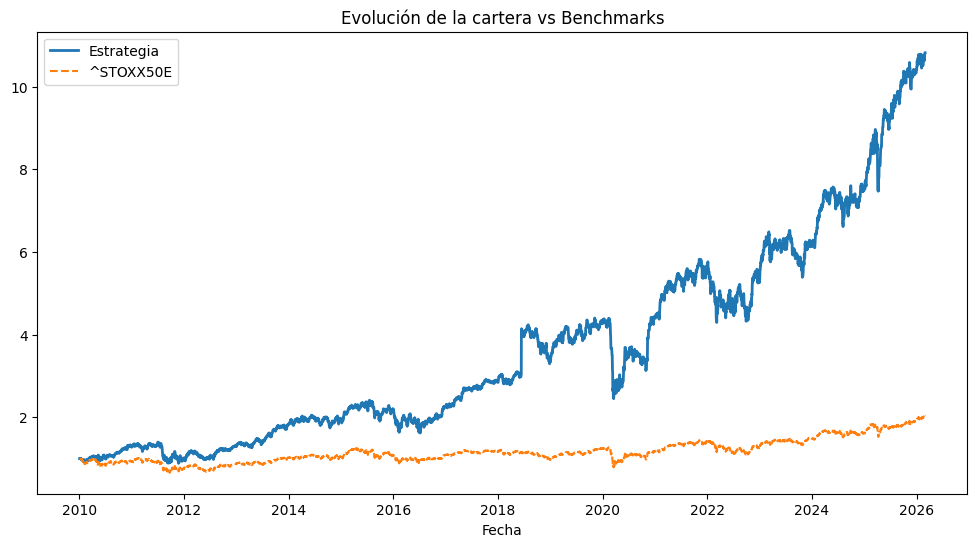

,Estrategia,^STOXX50E
Rentabilidad total,982.01%,103.41%
Rentabilidad anualizada,10.70%,3.08%
Volatilidad anualizada,21.31%,16.58%
Sharpe,0.58,0.27
Sortino,0.88,0.37
Max Drawdown,-44.31%,-38.27%
Calmar,0.24,0.08
Win rate,39.00%,36.00%
Mejor periodo,34.84%,10.35%
Peor periodo,-14.81%,-12.40%


In [12]:
start_date = "2010-01-02"
end_date = "2026-03-01"
universo = UniversoActivosDinamico(tickers_actuales=tickers, start_date=start_date, end_date=end_date, csv_cambios_path=r"eurostoxx50_historico_cambios.csv")
proveedor = YFinanceProvider()
fe = FeatureEngineer(criterio=5, ticker_indice="^STOXX50E")
modelo = RandomForestModel(
    n_estimators=250,
    max_depth=4,
    class_weight=None,
    random_state=528,
    positive_class_weight=10.0
)
estrategia = EstrategiaMLEquiponderada(modelo=modelo, n_activos_obj=15, umbral_salida=22)
engine = BacktestEngine(
    universo=universo,
    proveedor=proveedor,
    feature_engineer=fe,
    estrategia=estrategia,
    start_date=start_date,
    end_date=end_date,
    len_ventana=4,
    nominal=10000000
)

res2 = engine.print_results(bmks=["^STOXX50E"])

## Random Forest + EstrategiaMLMinVarAlphaTilt

[*********************100%***********************]  50 of 50 completed
[*********************100%***********************]  50 of 50 completed
c:\Users\jpuerta\OneDrive - Analistas Financieros Internacionales (Afi)\Documentos\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\ProveedorDatos.py:72: FutureWarning: DataFrameGroupBy.resample operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weekly = weekly.agg(


Modelo entrenado en fecha 2025-11-05


[*********************100%***********************]  1 of 1 completed


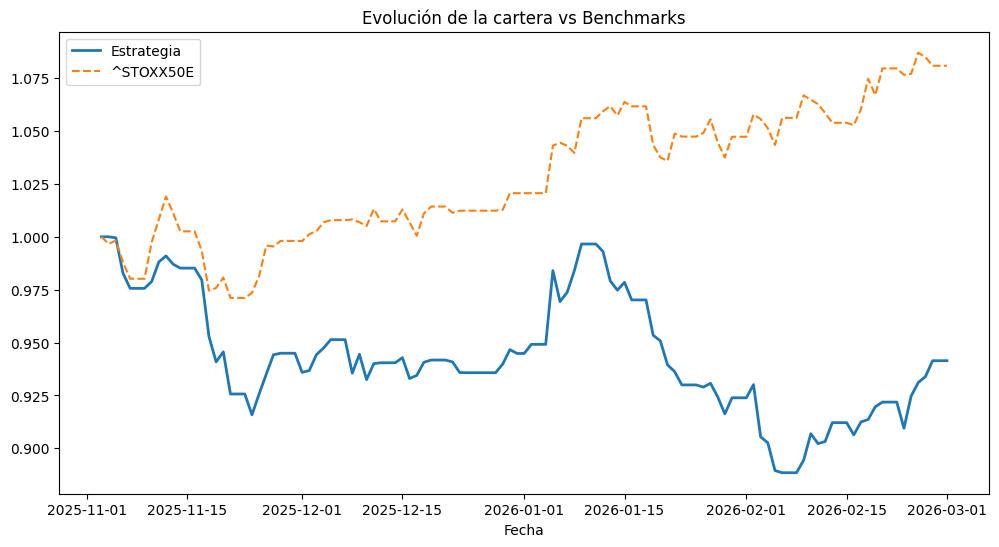

,Estrategia,^STOXX50E
Rentabilidad total,-5.86%,8.08%
Rentabilidad anualizada,-12.09%,18.06%
Volatilidad anualizada,13.35%,10.06%
Sharpe,-0.90,1.70
Sortino,-1.18,2.85
Max Drawdown,-11.15%,-4.70%
Calmar,-1.08,3.84
Win rate,35.59%,33.90%
Mejor periodo,3.67%,2.20%
Peor periodo,-2.73%,-1.88%


In [5]:
modelo = RandomForestModel(n_estimators=120, max_depth=4, class_weight=None, random_state=42, positive_class_weight=5.0)

estrategia = EstrategiaMLMinVarAlphaTilt(
    modelo=modelo,
    n_activos_obj=10,
    umbral_salida=15,      # universo candidato para optimización
    p_neutral=0.55,        # más conservador que 0.50
    alpha_scale=1.0,
    lambda_risk=3.0,       # subir para bajar volatilidad
    lambda_tc=0.001,       # subir para rotar menos
    w_max=0.2,
    turnover_max=0.20,
    no_trade_band=0.002,   # 40 bps de banda
    coste_transaccion=0.0005,  # 5 bps
    utility_buffer=0.0001,     # histéresis adicional
    min_hist_obs=26
)
engine = BacktestEngine(
    universo=universo,
    proveedor=proveedor,
    feature_engineer=fe,
    estrategia=estrategia,
    start_date=start_date,
    end_date=end_date,
    len_ventana=3,
    nominal=10000000
)

res3 = engine.print_results(bmks=["^STOXX50E"])

## XGBoostModel + EstrategiaMLMinVarAlphaTilt

[*********************100%***********************]  50 of 50 completed
[*********************100%***********************]  50 of 50 completed
c:\Users\jpuerta\OneDrive - Analistas Financieros Internacionales (Afi)\Documentos\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\ProveedorDatos.py:72: FutureWarning: DataFrameGroupBy.resample operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weekly = weekly.agg(


Modelo entrenado en fecha 2025-11-05


[*********************100%***********************]  1 of 1 completed


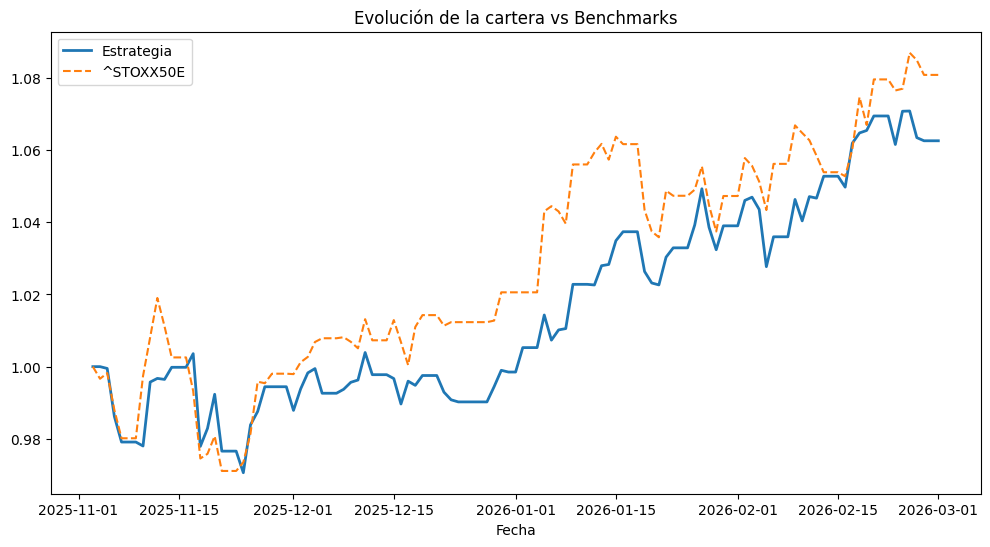

,Estrategia,^STOXX50E
Rentabilidad total,6.26%,8.08%
Rentabilidad anualizada,13.84%,18.06%
Volatilidad anualizada,9.38%,10.06%
Sharpe,1.43,1.70
Sortino,2.01,2.85
Max Drawdown,-3.29%,-4.70%
Calmar,4.21,3.84
Win rate,39.83%,33.90%
Mejor periodo,1.81%,2.20%
Peor periodo,-2.56%,-1.88%


In [6]:
modelo = XGBoostModel(n_estimators=180, max_depth=3, positive_class_weight=8.0)

estrategia = EstrategiaMLMinVarAlphaTilt(
    modelo=modelo,
    n_activos_obj=10,
    umbral_salida=15,      # universo candidato para optimización
    p_neutral=0.55,        # más conservador que 0.50
    alpha_scale=1.0,
    lambda_risk=5.0,       # subir para bajar volatilidad
    lambda_tc=0.001,       # subir para rotar menos
    w_max=0.20,
    turnover_max=0.20,
    no_trade_band=0.002,   # 40 bps de banda
    coste_transaccion=0.0005,  # 5 bps
    utility_buffer=0.0001,     # histéresis adicional
    min_hist_obs=26
)
engine = BacktestEngine(
    universo=universo,
    proveedor=proveedor,
    feature_engineer=fe,
    estrategia=estrategia,
    start_date=start_date,
    end_date=end_date,
    len_ventana=2,
    nominal=10000000
)

res4 = engine.print_results(bmks=["^STOXX50E"])